# BloodPressure.

## Exploratory data analysis Section:
    1. Univariate Analysis
    2. Bivariate Analysis
    3. Multi-variate Analysis

### Import the libraries

In [56]:
import sys, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# import the RTL module

from Melted import df_melt
from visualization import Plot


### Read the dataset

In [57]:
# !*pip install openpyxl
df = pd.read_csv('../Data/BP.csv')
df.head()
# df = pd.read_excel('BP.xlsx')

,day,date,hand,type,morning,noon,night
0,1.0,1405/2/8,R,Systolic,NaN,NaN,NaN
1,NaN,NaN,NaN,Diastolic,NaN,NaN,NaN
2,NaN,NaN,NaN,Pulse,NaN,NaN,NaN
3,NaN,NaN,L,Systolic,149.0,140.0,138.0
4,NaN,NaN,NaN,Diastolic,89.0,74.0,69.0


### Decompose the dataset into Left and Right Arm

In [58]:
df_half = df.loc[0:29].copy()
df_half['day'] = df_half['day'].ffill()
df_half['hand'] = df_half['hand'].ffill()
df_half['date'] = df_half['date'].ffill()

df_half = df_half.dropna()
col_num = ['morning', 'noon', 'night']
col_cat = ['hand', 'type']

# filtering the right hand
df_half_R = df_half[df_half['hand'] == 'R']
df_half_R = df_half_R.drop('hand' , axis=1)
df_half_R_s = df_half_R[df_half_R['type'] == 'Systolic'] 
df_half_R_d =  df_half_R[df_half_R['type'] == 'Diastolic'] 
df_half_R_p =  df_half_R[df_half_R['type'] == 'Pulse']

# filtering the left hand
df_half_L = df_half[df_half['hand'] == 'L']
df_half_L = df_half_L.drop('hand' , axis=1)
df_half_L_s = df_half_L[df_half_L['type'] == 'Systolic'] 
df_half_L_d =  df_half_L[df_half_L['type'] == 'Diastolic'] 
df_half_L_p =  df_half_L[df_half_L['type'] == 'Pulse']

In [59]:
df_half_R



,day,date,type,morning,noon,night
18,4.0,1405/2/11,Systolic,133.0,137.0,133.0
19,4.0,1405/2/11,Diastolic,60.0,73.0,76.0
20,4.0,1405/2/11,Pulse,56.0,78.0,71.0
24,5.0,1405/2/12,Systolic,130.0,116.0,119.0
25,5.0,1405/2/12,Diastolic,75.0,58.0,68.0
26,5.0,1405/2/12,Pulse,59.0,66.0,64.0


### Making Dataframe usable.

In [60]:
# melt the dataset.
df_p = df_melt(df_half_L_p)
df_s = df_melt(df_half_L_s)
df_d = df_melt(df_half_L_d)

    day       date   type time_of_day  measurement
0   3.0  1405/2/10  Pulse     morning         64.0
1   3.0  1405/2/10  Pulse        noon         67.0
2   3.0  1405/2/10  Pulse       night         69.0
3   4.0  1405/2/11  Pulse     morning         54.0
4   4.0  1405/2/11  Pulse        noon         72.0
5   4.0  1405/2/11  Pulse       night         74.0
6   5.0  1405/2/12  Pulse     morning         60.0
7   5.0  1405/2/12  Pulse        noon         65.0
8   5.0  1405/2/12  Pulse       night         68.0
9   1.0   1405/2/8  Pulse     morning         65.0
10  1.0   1405/2/8  Pulse        noon         83.0
11  1.0   1405/2/8  Pulse       night         62.0
12  2.0   1405/2/9  Pulse     morning         60.0
13  2.0   1405/2/9  Pulse        noon         64.0
14  2.0   1405/2/9  Pulse       night         69.0
    day       date      type time_of_day  measurement
0   3.0  1405/2/10  Systolic     morning        127.0
1   3.0  1405/2/10  Systolic        noon        113.0
2   3.0  1405/2/10  Sy

In [61]:
melted_list = [df_p , df_s , df_d]
name = ['pulse', 'Systolic', 'Diastolic']

for d, n in zip(melted_list,name):
    print('-'*24 , f'Average value for {n}', ''*25)
    print(d.groupby('time_of_day', observed=False )['measurement'].mean())
    print('-'*50)


------------------------ Average value for pulse 
time_of_day
morning    60.6
noon       70.2
night      68.4
Name: measurement, dtype: float64
--------------------------------------------------
------------------------ Average value for Systolic 
time_of_day
morning    139.6
noon       132.0
night      136.6
Name: measurement, dtype: float64
--------------------------------------------------
------------------------ Average value for Diastolic 
time_of_day
morning    79.8
noon       71.0
night      76.0
Name: measurement, dtype: float64
--------------------------------------------------


# this is were you develope T-Test to comapare if 
# getting BP with Right or Left hand would differ 
# in any case.


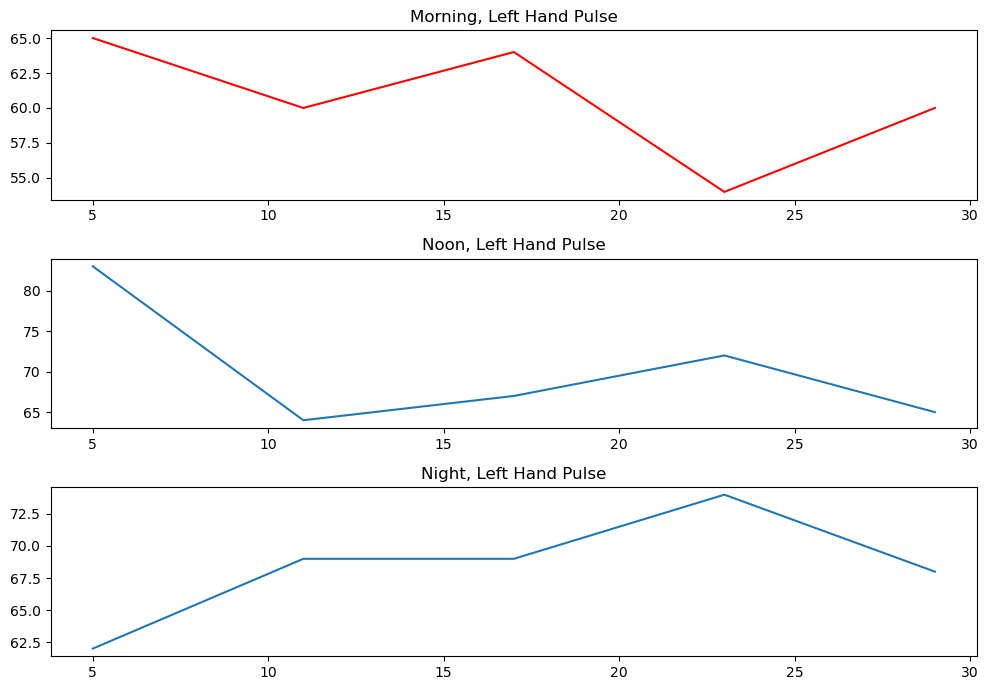

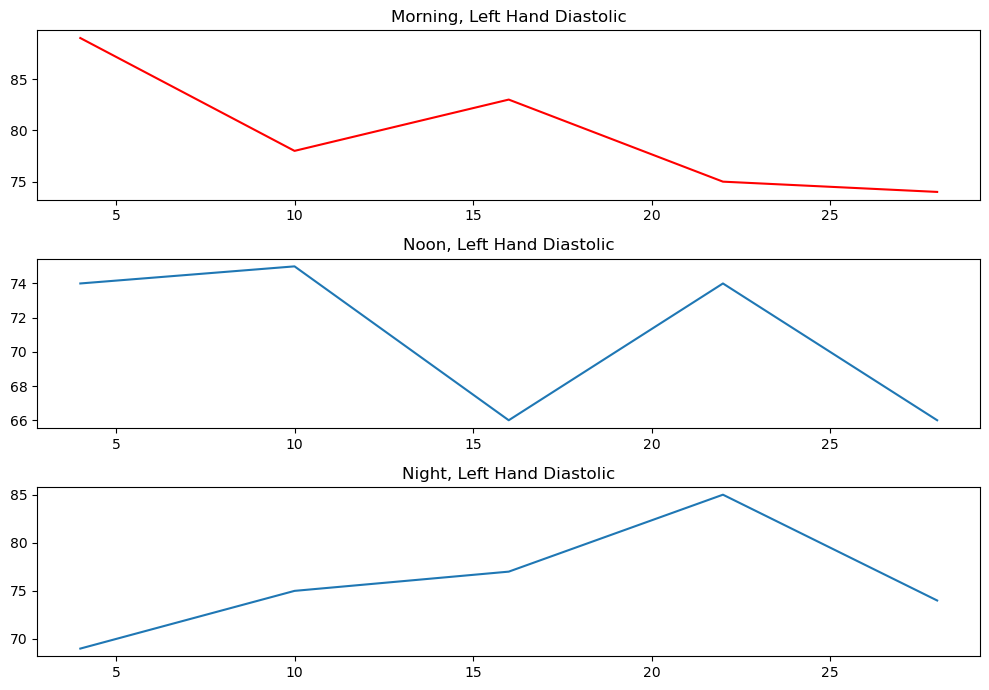

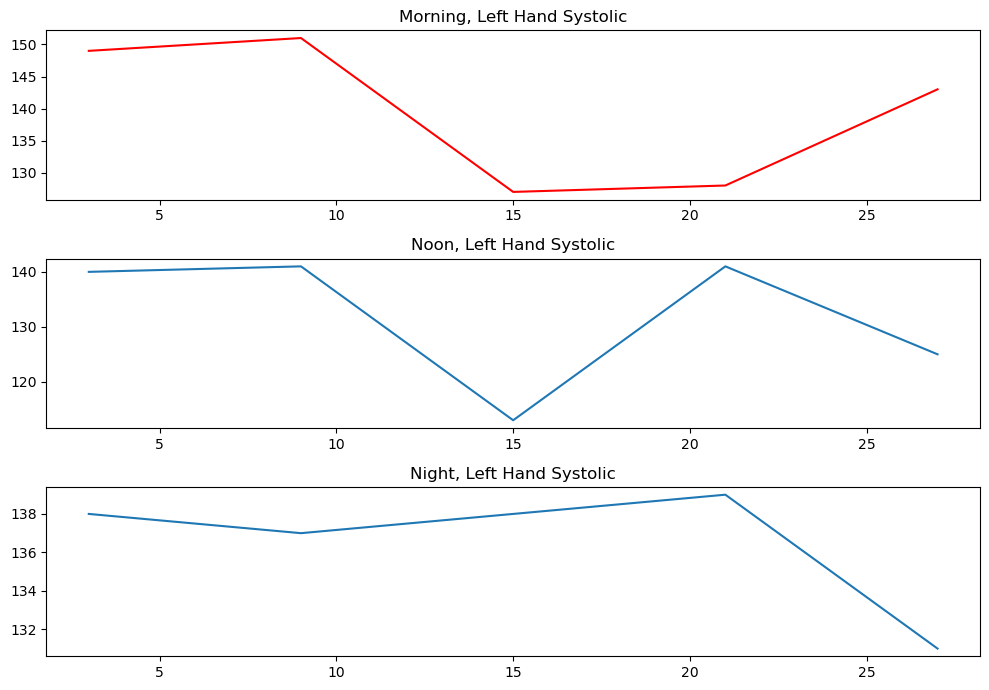

In [62]:
# Analysis of Left hand

datasets = [df_half_L_p , df_half_L_d , df_half_L_s]
names = ['Pulse' , 'Diastolic', 'Systolic']

Plot(datasets, names)

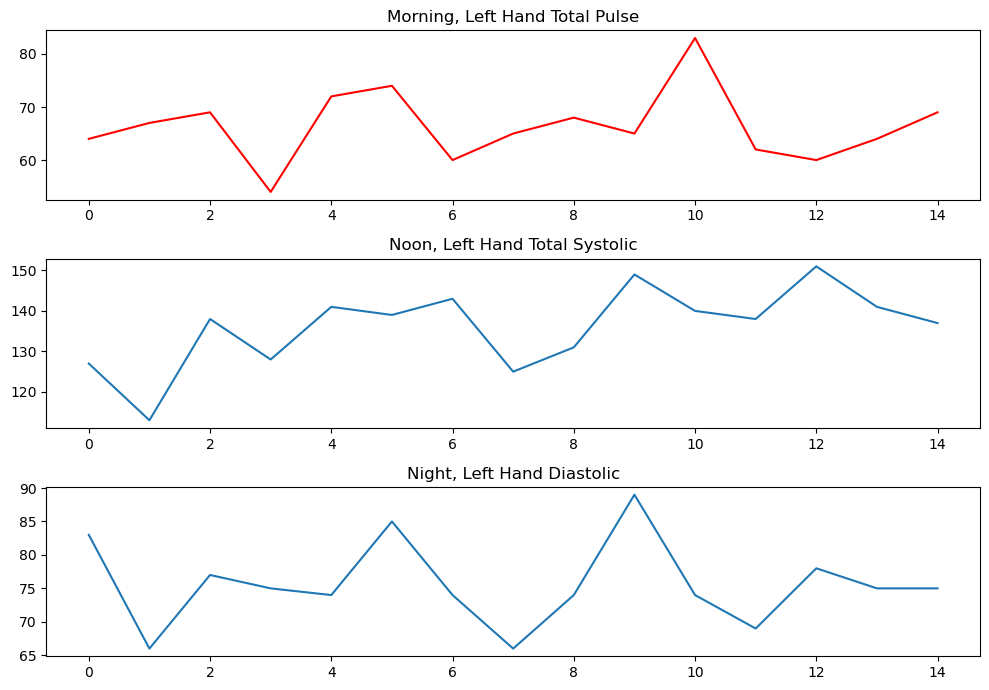

In [ ]:
fig, ax = plt.subplots(3,1,figsize=(10,7))

ax[0].plot(df_p['measurement'], color = 'red')
ax[0].set_title('Morning, Left Hand Total Pulse')

ax[1].plot(df_s['measurement'])
ax[1].set_title('Noon, Left Hand Total Systolic')

ax[2].plot(df_d['measurement'])
ax[2].set_title('Night, Left Hand Diastolic')
plt.tight_layout()
plt.show()